# Bounded Fermi–Dirac integral: corrected numerical supplement

Executed research notebook. All tables, errors and figures are generated by the cells below. **Run all cells from a fresh kernel.** Requirements: Python 3.12+, NumPy, SciPy, Matplotlib, mpmath; Jupyter/ipykernel for interactive use.

Bounded calculations use the **unnormalized** integral with **physical temperature**
$$F_c(\mu;T,a)=\int_0^a\frac{x^c}{1+e^{(x-\mu)/T}}\,dx,\qquad c>-1,\ a,T>0.$$
The manuscript's normalized three-argument convention is obtained by dividing by $\Gamma(c+1)$. Its Poisson exponent multiplier equals $1/T$ here. The Hurwitz plots in Section 8 use a separately labeled **normalized complete function**, allowing analytic continuation to the requested negative orders.

Four computations are kept distinct: raw sign-split series, numerical Brent inversion of an approximation, explicit Bell/Taylor inversion, and implicit asymptotic Sommerfeld inversion. The old subtraction-based Poisson routine is retained **only for reproducibility diagnostics**. Its replacement uses an explicitly specified binomial average of Fourier partial traces; this is a change in numerical summation and must be described in the manuscript before using these new Poisson results.

PDF and SVG preserve vector curves. Every export specifies `dpi=300` (applies to rasterized components); PNG previews are also 300 dpi. Typography, grayscale styles, markers, figure size and label placement follow the supplied script. Mathtext replaces external LaTeX so execution needs no TeX installation.

In [1]:
from pathlib import Path
import sys, json, csv, platform, math, warnings
import numpy as np
import scipy
import mpmath as mp
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import quad, IntegrationWarning
from scipy.special import expit
from scipy.optimize import brentq
from IPython.display import display
%matplotlib inline
warnings.filterwarnings('error', category=IntegrationWarning)
FIG=Path('figures'); DATA=Path('data')
FIG.mkdir(exist_ok=True); DATA.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize':(3.5,3.0), 'figure.dpi':120,
 'savefig.dpi':300,'font.size':9,'axes.labelsize':9,'xtick.labelsize':8,
 'ytick.labelsize':8,'font.family':'serif','mathtext.fontset':'dejavuserif',
 'text.usetex':False,'pdf.fonttype':42,'ps.fonttype':42,'svg.fonttype':'path',
 'lines.linewidth':1.2,'lines.markersize':4})
versions={'python':platform.python_version(),'numpy':np.__version__,
 'scipy':scipy.__version__,'matplotlib':matplotlib.__version__,'mpmath':mp.__version__}
print(json.dumps(versions,indent=2))
styles={10:dict(ls='--',marker='^',color='black'),
 30:dict(ls=':',marker='s',color='dimgray'),
 50:dict(ls='-.',marker='o',color='darkgray'),
 100:dict(ls='-',marker='D',color='0.35')}
figure_names=[]
def style(N,n):return dict(**styles[N],markevery=max(1,int(n*.12)),markerfacecolor='white')
def labels(ax,x=r'$\mu$',y=r'$F_{\leq a}$'):
 ax.text(1.02,-.1,x,transform=ax.transAxes,ha='left',va='bottom',fontsize=10)
 ax.text(-.1,1.02,y,transform=ax.transAxes,ha='left',va='bottom',fontsize=10)
 ax.grid(True,ls=':',alpha=.6)
 if y=='Ratio':
  from matplotlib.ticker import FormatStrFormatter
  ax.yaxis.set_major_formatter(FormatStrFormatter('%.6f'))
def savefig(name):
 fig=plt.gcf()
 for ext in ('pdf','svg','png'):
  fig.savefig(FIG/(name+'.'+ext),format=ext,dpi=300,bbox_inches='tight',pad_inches=.04)
 figure_names.append(name);plt.show();plt.close(fig)
def write_csv(name,rows):
 with (DATA/name).open('w',newline='') as f:
  w=csv.DictWriter(f,fieldnames=list(rows[0]));w.writeheader();w.writerows(rows)
def show_rows(rows):
 # No pandas dependency; stdout tables remain visible in exported notebooks.
 for row in rows:print(' | '.join(f'{k}={v:.8g}' if isinstance(v,float) else f'{k}={v}' for k,v in row.items()))

{
  "python": "3.12.14",
  "numpy": "2.3.5",
  "scipy": "1.17.0",
  "matplotlib": "3.10.8",
  "mpmath": "1.4.1"
}


## 1. Corrected evaluators and explicit tolerances
The corrected inner moment is
$$L_c(b,\lambda)=\frac{b^{c+1}}{c+1}{}_1F_1(1;c+2;-\lambda b).$$
Its gamma version uses $e^{-i\pi(c+1)}\gamma(c+1,-\lambda b+i0)$, not $(-1)^c\gamma(c+1,-\lambda b)$. The split is clipped to $[0,a]$ outside the interior regime. The raw half-order formula is not accelerated.

Quadrature requests `epsabs=epsrel=1e-12`; Brent uses `xtol=1e-12`, `rtol=4*eps` explicitly. These are termination settings, **not accuracy guarantees**. Selected reference values are cross-checked with 60- and 80-digit mpmath quadrature. No claim of universal $10^{-15}$ accuracy is made.

In [2]:
"""Bounded Fermi--Dirac integrals: explicit domains and independent inverses.
All forward values use the UNNORMALIZED integral, with physical temperature T.
"""
import math
import numpy as np
from scipy.integrate import quad
from scipy.optimize import brentq
from scipy.special import expit, gamma, gammainc, gammaincc, hyp1f1, erfcx, dawsn, zeta
from numpy.polynomial import polynomial as poly

QUAD_EPS = 1e-12
ROOT_XTOL = 1e-12
ROOT_RTOL = 4*np.finfo(float).eps

def check(c, a, T):
    if not (c > -1 and a > 0 and T > 0):
        raise ValueError('Require c > -1, a > 0, T > 0.')

def weighted_quad(func, c, a, eps=QUAD_EPS):
    # QUADPACK algebraic weight handles the integrable singularity at zero.
    return quad(func, 0., a, weight='alg', wvar=(c, 0.),
                epsabs=eps, epsrel=eps, limit=400)[0]

def f_quad(mu, c=.5, a=10., T=1.):
    check(c,a,T)
    return weighted_quad(lambda x: expit((mu-x)/T),c,a)

def f_quad_substitution(mu, c=.5, a=10., T=1.):
    # Independent endpoint substitution for selected reference checks.
    check(c,a,T)
    mass=a**(c+1)/(c+1)
    f=lambda t: mass*expit((mu-a*t**(1/(c+1)))/T)
    split=(mu/a)**(c+1) if 0<mu<a else None
    return quad(f,0.,1.,points=[split] if split else None,
                epsabs=QUAD_EPS,epsrel=QUAD_EPS,limit=400)[0]

def f_zero(mu,a=10.,T=1.):
    # Stable exact c=0 identity, including large positive chemical potentials.
    if mu>=a:
        return a+T*(np.logaddexp(0.,-mu/T)-np.logaddexp(0.,(a-mu)/T))
    return T*(np.logaddexp(0.,mu/T)-np.logaddexp(0.,(mu-a)/T))

def scaled_upper(s,x):
    """H_s(x)=exp(x) Gamma(s,x), x>=0, s>0.
    Large-x asymptotic expansion stops before term growth or at roundoff.
    """
    if x < 400.:
        return math.exp(x)*gamma(s)*gammaincc(s,x)
    term=1.; total=1.
    for k in range(1,200):
        new=term*(s-k)/x
        if abs(new)>abs(term): break
        total+=new
        if abs(new)<2e-16*abs(total): break
        term=new
    return x**(s-1)*total

def inner_moment(r,b,lam):
    if b==0: return 0.
    return b**(r+1)/(r+1)*hyp1f1(1.,r+2.,-lam*b)

def outer_moment(r,b,a,lam):
    if b>=a: return 0.
    s=r+1
    if b==0:
        return gamma(s)*gammainc(s,lam*a)/lam**s
    return (scaled_upper(s,lam*b)-math.exp(-lam*(a-b))*scaled_upper(s,lam*a))/lam**s

def split_moments(mu,r,a,T,n):
    b=float(np.clip(mu,0.,a)); lam=n/T
    inner=math.exp(-lam*(mu-b))*inner_moment(r,b,lam) if b else 0.
    outer=math.exp(lam*(mu-b))*outer_moment(r,b,a,lam) if b<a else 0.
    return inner,outer

def f_gamma(mu,c=.5,a=10.,T=1.,N=100):
    """Raw sign-split partial sum. This is not a machine-precision promise."""
    check(c,a,T)
    b=float(np.clip(mu,0.,a))
    terms=[]
    for n in range(1,N+1):
        inner,outer=split_moments(mu,c,a,T,n)
        terms.append((-1.)**(n-1)*(outer-inner))
    return b**(c+1)/(c+1)+math.fsum(terms)

def gamma_remainder_bound(mu,c=.5,a=10.,T=1.,N=100):
    return sum(split_moments(mu,c,a,T,N+1))

def f_half(mu,a=10.,N=100):
    """Original half-order erfcx/Dawson formula, T=1, 0<=mu<a."""
    if not 0<=mu<a: raise ValueError('Require 0 <= mu < a.')
    terms=[]
    for n in range(1,N+1):
        innerpart=np.sqrt(np.pi)/(2*n**1.5)*(erfcx(np.sqrt(n*mu))+2/np.sqrt(np.pi)*dawsn(np.sqrt(n*mu)))
        tail=math.exp(n*(mu-a))*scaled_upper(1.5,n*a)/n**1.5
        terms.append((-1.)**(n-1)*(innerpart-tail))
    return 2/3*mu**1.5+math.fsum(terms)

def poisson_modes(mu,c=.5,a=10.,T=1.,N=60):
    check(c,a,T)
    vals=[]
    for m in range(1,N+1):
        J=sum(split_moments(mu,c+1,a,T,m))/gamma(c+2)
        vals.append((-1.)**(m-1)*m*J/T)
    return np.array(vals)

def f_poisson(mu,c=.5,a=10.,T=1.,L=30):
    """Binomial mean of partial traces S_L,...,S_(2L).
    Uses closed-form moments, never forward quadrature or a reference root.
    """
    if L<2: raise ValueError('Require L >= 2.')
    vals=poisson_modes(mu,c,a,T,2*L)
    sums=np.cumsum(vals,dtype=np.longdouble)
    weights=np.array([math.comb(L,j)/2.**L for j in range(L+1)],dtype=np.longdouble)
    trace=np.dot(weights,sums[L-1:2*L])
    boundary=a**(c+1)/(c+1)*expit((mu-a)/T)
    return float(gamma(c+1)*trace+boundary)

def poisson_bound(c=.5,a=10.,T=1.,L=30):
    """Uniform exact-arithmetic absolute truncation bound (not rounding error)."""
    return a**(c+2)/((c+1)*(c+2)*T)*(16*L+8)/8.**L

def trace_integral(mu,c=.5,a=10.,T=1.):
    tr=weighted_quad(lambda x:expit((mu-x)/T)*expit((x-mu)/T)/T,c+1,a)/gamma(c+2)
    return gamma(c+1)*tr+a**(c+1)/(c+1)*expit((mu-a)/T)

def invert(y,c=.5,a=10.,T=1.,method='poisson',L=30):
    """Numerical inversion; distinct from analytic Taylor/Sommerfeld inverses."""
    check(c,a,T)
    cap=a**(c+1)/(c+1)
    if not 0<y<cap: raise ValueError('Target must lie strictly inside (0, capacity).')
    if method=='poisson': f=lambda u:f_poisson(u,c,a,T,L)
    elif method=='quadrature': f=lambda u:f_quad(u,c,a,T)
    else: raise ValueError('Unknown method.')
    lo=-T; hi=a+T; step=a+T
    for _ in range(80):
        flo=f(lo)-y; fhi=f(hi)-y
        if flo<=0 and fhi>=0: break
        if flo>0: lo-=step
        if fhi<0: hi+=step
        step*=2
    else: raise RuntimeError('Could not bracket root.')
    return brentq(lambda u:f(u)-y,lo,hi,xtol=ROOT_XTOL,rtol=ROOT_RTOL,maxiter=200)

def logistic_polynomials(K):
    # P_0(v)=v; P_(n+1)(v)=v(1-v) P_n'(v).
    ps=[np.array([0.,1.])]
    for n in range(K):
        ps.append(poly.polymul(poly.polyder(ps[-1]),[0.,1.,-1.]))
    return ps

def forward_taylor(mu0,c=.5,a=10.,T=1.,K=6):
    check(c,a,T)
    ps=logistic_polynomials(K)
    return np.array([weighted_quad(lambda x,p=p:poly.polyval(expit((mu0-x)/T),p),c,a)/(T**n*math.factorial(n))
                     for n,p in enumerate(ps)])

def ordinary_bell(n,k,x):
    """Coefficient [t^n](sum_(j>=1) x_j t^j)^k; no factorial convention ambiguity."""
    out=np.array([1.]); base=np.r_[0.,x]
    for _ in range(k): out=poly.polymul(out,base)[:n+1]
    return out[n] if n<len(out) else 0.

def inverse_coefficients(a):
    K=len(a)-1; a1=a[1]
    if a1<=0: raise ValueError('Positive first derivative required.')
    b=a[2:]/a1; co=[1/a1]
    for k in range(2,K+1):
        value=math.fsum((-1.)**j*math.comb(k+j-1,j)*ordinary_bell(k-1,j,b) for j in range(1,k))
        co.append(value/(k*a1**k))
    return np.array(co)

def inverse_taylor(y,mu0,a,co):
    # Explicit polynomial evaluation: no root finding.
    return mu0+poly.polyval(y-a[0],np.r_[0.,co])

def series_power(r,p,n):
    """Truncated real power of a series with constant coefficient one."""
    h=np.array(r,dtype=float).copy(); h[0]-=1
    result=np.zeros(n+1); result[0]=1.; term=np.array([1.]); choose=1.
    for k in range(1,n+1):
        term=poly.polymul(term,h)[:n+1]
        choose*= (p-k+1)/k
        result[:len(term)]+=choose*term
    return result

def sommerfeld_coefficients(c,K=3):
    p=c+1; A=np.ones(K+1)
    for k in range(1,K+1):
        falling=math.prod(c-j for j in range(2*k-1))
        A[k]=p*2*(1-2.**(1-2*k))*zeta(2*k)*falling
    r=np.zeros(K+1);r[0]=1
    for n in range(1,K+1):
        val=0.
        for k in range(n+1):val+=A[k]*series_power(r,p-2*k,n-k)[n-k]
        r[n]=-val/p
    return A,r[1:]

def tail_series(mu,c,a,T,N=100):
    if not mu<a: raise ValueError('Convergent exponential tail requires mu < a.')
    return T**(c+1)*math.fsum((-1.)**(n-1)*math.exp(n*(mu-a)/T)*scaled_upper(c+1,n*a/T)/n**(c+1) for n in range(1,N+1))

def sommerfeld_forward(mu,c,a,T,K=3):
    if not 0<mu<a: raise ValueError('Use an interior positive chemical potential.')
    A,_=sommerfeld_coefficients(c,K)
    return mu**(c+1)/(c+1)*math.fsum(A[k]*(T/mu)**(2*k) for k in range(K+1))-tail_series(mu,c,a,T)

def sommerfeld_inverse(y,c,a,T,K=3,tol=ROOT_XTOL):
    """Implicit asymptotic fixed-point solve; no exact forward root used.
    Restricted to an interior, strongly degenerate regime. Raises on failure.
    """
    _,b=sommerfeld_coefficients(c,K)
    mu=((c+1)*y)**(1/(c+1))
    for step in range(100):
        if not 0<mu<a: raise ValueError('Sommerfeld iteration left the interior regime.')
        u=((c+1)*(y+tail_series(mu,c,a,T)))**(1/(c+1))
        candidate=u*(1+math.fsum(b[k-1]*(T/u)**(2*k) for k in range(1,K+1)))
        if abs(candidate-mu)<tol:return candidate,step+1
        mu=candidate
    raise RuntimeError('Sommerfeld fixed-point iteration did not converge.')

In [3]:
print(f'Quadrature epsabs=epsrel={QUAD_EPS:g}; Brent xtol={ROOT_XTOL:g}, rtol={ROOT_RTOL:.17g}')
def invert_forward(y,forward,c=.5,a=10.,T=1.):
 check(c,a,T);cap=a**(c+1)/(c+1)
 if not 0<y<cap:raise ValueError('Target must be strictly between zero and saturation.')
 lo=-T;hi=a+T;step=a+T
 for k in range(80):
  fl=forward(lo)-y;fh=forward(hi)-y
  if not (np.isfinite(fl) and np.isfinite(fh)):raise FloatingPointError('Nonfinite bracket residual')
  if fl<=0<=fh:break
  if fl>0:lo-=step
  if fh<0:hi+=step
  step*=2
 else:raise RuntimeError('No sign-changing bracket after 80 expansions')
 root,result=brentq(lambda u:forward(u)-y,lo,hi,xtol=ROOT_XTOL,rtol=ROOT_RTOL,maxiter=200,full_output=True)
 if not result.converged:raise RuntimeError('Brent did not converge')
 return root

def F_num(mu,a):return f_quad(mu,c=.5,a=a,T=1.)
def safe_bounded_selvaggi(mu,a,n_terms):
 return f_half(mu,a,n_terms) if 0<=mu<a else f_gamma(mu,c=.5,a=a,N=n_terms)
def invert_selvaggi_safe(y_target,a_bound,n_terms):
 return invert_forward(y_target,lambda u:safe_bounded_selvaggi(u,a_bound,n_terms),a=a_bound)
def invert_poisson_series(y_target,a,T,n_modes):
 if n_modes<4 or n_modes%2:raise ValueError('Use an even mode budget N >= 4.')
 return invert_forward(y_target,lambda u:f_poisson(u,c=.5,a=a,T=T,L=n_modes//2),a=a,T=T)

def mp_bounded(mu,c=.5,a=10.,T=1.,dps=60):
 with mp.workdps(dps):
  mu,c,a,T=map(mp.mpf,map(str,(mu,c,a,T)));s=c+1
  if s<=0:raise ValueError('The bounded defining integral requires c > -1.')
  # x=a*t^(1/s) removes the endpoint weight exactly.
  fun=lambda t:a**s/s/(1+mp.exp((a*t**(1/s)-mu)/T))
  pts=[mp.mpf(0)]
  if 0<mu<a:pts.append((mu/a)**s)
  pts.append(mp.mpf(1))
  return +mp.quad(fun,pts)
reference_checks=[]
for mu,c,a,T in [(1,.5,10,1),(.1,.5,10,1),(9.5,.5,10,1),(1,-.75,10,1),(1,0,10,1)]:
 hi=mp_bounded(mu,c,a,T,80);lo=mp_bounded(mu,c,a,T,60)
 assert abs(hi-lo)<mp.mpf('1e-45')
 reference_checks.append(dict(mu=mu,c=c,a=a,T=T,reference_80dps=mp.nstr(hi,80),
   double_error=float(abs(mp.mpf(f_quad(mu,c,a,T))-hi))))
write_csv('reference_checks.csv',reference_checks);show_rows(reference_checks)
assert abs(f_zero(1)-f_gamma(1,c=0,N=100))<2e-14

Quadrature epsabs=epsrel=1e-12; Brent xtol=1e-12, rtol=8.8817841970012523e-16
mu=1 | c=0.5 | a=10 | T=1 | reference_80dps=1.3959663933366890538549334943102919061827314476907157261202610724821099216460333 | double_error=1.625849e-17
mu=0.1 | c=0.5 | a=10 | T=1 | reference_80dps=0.73323688852669844396650648311885528012848432633705245417527508540307668900717301 | double_error=1.1680448e-16
mu=9.5 | c=0.5 | a=10 | T=1 | reference_80dps=18.210861675487061240379558622614163153098638470625404751869244676479014208061844 | double_error=1.6548586e-15
mu=1 | c=-0.75 | a=10 | T=1 | reference_80dps=3.1874291989969384504629129851620993820955965902107007108349848411605109001427322 | double_error=1.2171559e-16
mu=1 | c=0 | a=10 | T=1 | reference_80dps=1.3131382853284995752326453562178120036642674548614529104397710951254046279132169 | double_error=1.6467904e-16


## 2. Poisson summation repair and exact-arithmetic bound
The old interior derivative subtraction becomes poorly conditioned near the endpoints. The replacement uses the same closed-form finite-interval Fourier moments, but averages partial traces instead of subtracting singular high derivatives. It never calls forward quadrature or a reference root.

Let $q=e^{-|x-\mu|/T}$ and $S_M(q)=\sum_{m=1}^M(-1)^{m-1}m q^m$. With $N=2L$ modes, use
$$B_L(q)=2^{-L}\sum_{j=0}^L\binom Lj S_{L+j}(q).$$
The exact scalar residual is
$$\frac{q}{(1+q)^2}-B_L(q)=\frac{(-1)^Lq^{L+1}(1-q)^{L-1}}{2^L(1+q)^2}\big[(L+1)(1-q)-2Lq^2\big].$$
For $L\ge2$, using $q(1-q)\le1/4$ gives the conservative bound $(16L+8)/8^L$. Integration against the nonnegative finite source gives
$$|F_c-F_{c,2L}^{\rm P}|\le\frac{a^{c+2}}{(c+1)(c+2)T}\frac{16L+8}{8^L}.$$
This bound controls mathematical truncation, not floating-point or special-function error. The scalar identity follows by summing the finite geometric derivative; the tests below check its implementation. A finite averaged approximation need not be assumed globally monotone: bracketing, residuals and tested-domain errors are reported separately.

In [4]:
for L in [2,5,15,25,50]:
 q=np.linspace(0,1,301)
 partial=np.cumsum(np.array([(-1.)**(m-1)*m*q**m for m in range(1,2*L+1)]),axis=0)
 mean=sum(math.comb(L,j)/2.**L*partial[L+j-1] for j in range(L+1))
 residual=q/(1+q)**2-mean
 exact=(-1.)**L*q**(L+1)*(1-q)**(L-1)/(2.**L*(1+q)**2)*((L+1)*(1-q)-2*L*q*q)
 assert np.max(abs(residual-exact))<8e-14
 assert max(abs(exact))<=(16*L+8)/8.**L
orders=[-.75,0.,.3,.5,2.]
general=[]
for c in orders:
 for a in [2.5,10.]:
  for T in [.4,1.,2.]:
   for mu in [-2*T,0.,.01*a,.5*a,.95*a,a,a+2*T]:
    ref=f_quad(mu,c,a,T);raw=f_gamma(mu,c,a,T,N=100);v=f_poisson(mu,c,a,T,L=30)
    bound=gamma_remainder_bound(mu,c,a,T,N=100)
    assert abs(raw-ref)<=bound+2e-10*(1+abs(ref))
    assert abs(v-ref)/(1+abs(ref))<3e-11
    general.append(dict(c=c,a=a,T=T,mu=mu,reference=ref,gamma_N100=raw,
      gamma_error=abs(raw-ref),gamma_bound=bound,poisson_N60=v,poisson_error=abs(v-ref)))
write_csv('general_order.csv',general)
print('General-order / endpoint cases:',len(general))
print('Maximum Poisson scaled error:',max(r['poisson_error']/(1+abs(r['reference'])) for r in general))
print('The finite grid supports this implementation; it does not prove all-parameter floating-point accuracy.')

General-order / endpoint cases: 210
Maximum Poisson scaled error: 1.0384015532075052e-13
The finite grid supports this implementation; it does not prove all-parameter floating-point accuracy.


## 3. Reproduce the original failures and compare the replacement
The next cell embeds only the original imports and function definitions. No installation commands, warning suppression, original plotting, or top-level data generation is executed. The isolated `legacy` namespace avoids replacing the corrected functions. `NaN` from the original inverse is recorded as a failure, not discarded.

In [5]:
legacy={}
exec(compile("import numpy as np\nimport matplotlib.pyplot as plt\nfrom scipy.integrate import quad\nfrom scipy.optimize import root_scalar\nfrom scipy.special import gamma, gammaincc, erfcx, dawsn, hyp1f1, zeta\nimport warnings\n\ndef get_style(n, base_symbol='F', sub_script='\\\\le a', array_len=1000):\n    m_every = int(array_len * 0.12)\n    styles = {10: {'ls': '--', 'marker': '^', 'color': 'black'}, 30: {'ls': ':', 'marker': 's', 'color': 'dimgray'}, 50: {'ls': '-.', 'marker': 'o', 'color': 'darkgray'}}\n    s = styles[n].copy()\n    s['label'] = f'${base_symbol}_{{ {sub_script} }}^{{(n)}} \\\\quad (n={n})$'\n    s['markevery'] = m_every\n    return s\n\ndef get_style_high(n, base_symbol='F', sub_script='\\\\le a', array_len=1000):\n    m_every = int(array_len * 0.12)\n    st = {30: {'ls': '--', 'marker': '^', 'color': 'black'}, 50: {'ls': ':', 'marker': 's', 'color': 'dimgray'}, 100: {'ls': '-.', 'marker': 'o', 'color': 'darkgray'}}[n]\n    st['markevery'] = m_every\n    return st\n\ndef F_num(mu, a):\n    value, _ = quad(lambda x: np.sqrt(x) / (1.0 + np.exp(x - mu)), 0.0, a, epsabs=1e-12, epsrel=1e-12, limit=300)\n    return value\n\ndef invert_exact(y_target, a_bound):\n\n    def objective(mu):\n        return F_num(mu, a_bound) - y_target\n    try:\n        return root_scalar(objective, bracket=[0.01, a_bound - 0.01], method='brentq').root\n    except ValueError:\n        return np.nan\n\ndef safe_bounded_selvaggi(mu, a, n_terms):\n    if mu < 0:\n        return np.nan\n    total = 2.0 / 3.0 * mu ** 1.5\n    for p in range(1, n_terms + 1):\n        erfc_part = erfcx(np.sqrt(p * mu))\n        erfi_part = 2.0 / np.sqrt(np.pi) * dawsn(np.sqrt(p * mu))\n        term_1 = np.sqrt(np.pi) / 2.0 * ((-1) ** (p - 1) / p ** 1.5) * (erfc_part + erfi_part)\n        x = p * a\n        if p * mu < 500:\n            gamma_pa = gamma(1.5) * gammaincc(1.5, x)\n            term_2 = (-1) ** (p - 1) / p ** 1.5 * np.exp(p * mu) * gamma_pa\n        else:\n            asymp_gamma = x ** 0.5 * (1.0 + 0.5 / x - 0.25 / x ** 2 + 0.375 / x ** 3)\n            term_2 = (-1) ** (p - 1) / p ** 1.5 * np.exp(p * (mu - a)) * asymp_gamma\n        total += term_1 - term_2\n    return total\n\ndef invert_selvaggi_safe(y_target, a_bound, n_terms):\n\n    def objective(mu):\n        return safe_bounded_selvaggi(mu, a_bound, n_terms) - y_target\n    try:\n        return root_scalar(objective, bracket=[0.01, a_bound - 0.01], method='brentq').root\n    except ValueError:\n        return np.nan\n\ndef I_in_correct(mu, m, T, c):\n    lam = m * T\n    return mu ** (c + 2.0) / gamma(c + 3.0) * hyp1f1(1.0, c + 3.0, -lam * mu)\n\ndef I_out_correct(mu, a, m, T, c):\n    lam = m * T\n    s = c + 2.0\n    x_mu = lam * mu\n    x_a = lam * a\n    with np.errstate(over='ignore', invalid='ignore'):\n        val = np.exp(x_mu) / lam ** s * (gammaincc(s, x_mu) - gammaincc(s, x_a))\n    if not (np.isnan(val) or np.isinf(val)):\n        return val\n\n    def scaled_gammaincc(x):\n        res = 1.0\n        term = 1.0\n        for k in range(1, 20):\n            term *= (s - k) / x\n            res += term\n        return res * x ** (s - 1.0) / gamma(s)\n    term_mu = scaled_gammaincc(x_mu)\n    term_a = scaled_gammaincc(x_a) * np.exp(x_mu - x_a)\n    return (term_mu - term_a) / lam ** s\n\ndef rho_even_derivative(mu, c, k):\n    q = c + 1.0\n    coefficient = 1.0\n    for j in range(2 * k):\n        coefficient *= q - j\n    return coefficient * mu ** (q - 2 * k) / gamma(c + 2.0)\n\ndef alternating_abel_sum(k):\n    if k == 0:\n        return -0.5\n    return -(1.0 - 2.0 ** (1.0 - 2.0 * k)) * zeta(2.0 * k)\n\ndef F_poisson_regularized(mu, a, T=1.0, c=0.5, N=100, K=3):\n    m = np.arange(1, N + 1, dtype=float)\n    raw_terms = np.empty(N)\n    for j, mj in enumerate(m.astype(int)):\n        Iin = I_in_correct(mu, mj, T, c)\n        Iout = I_out_correct(mu, a, mj, T, c)\n        raw_terms[j] = -T * (-1.0) ** mj * mj * (Iin + Iout)\n    asymptotic_terms = np.zeros(N)\n    asymptotic_exact_sum = 0.0\n    for k in range(K + 1):\n        coefficient = -2.0 * rho_even_derivative(mu, c, k) / T ** (2 * k)\n        if k == 0:\n            asymptotic_terms += coefficient * (-1.0) ** m\n        else:\n            asymptotic_terms += coefficient * (-1.0) ** m / m ** (2 * k)\n        asymptotic_exact_sum += coefficient * alternating_abel_sum(k)\n    regular_remainder_sum = np.sum(raw_terms - asymptotic_terms)\n    boundary_term = a ** (c + 1.0) / gamma(c + 2.0) / (1.0 + np.exp(T * (a - mu)))\n    return T ** (c + 1.0) * gamma(c + 1.0) * (boundary_term + asymptotic_exact_sum + regular_remainder_sum)\n\ndef invert_poisson_series(y_target, a, T, n_modes):\n\n    def objective(mu):\n        return F_poisson_regularized(mu, a, T=T, c=0.5, N=n_modes, K=3) - y_target\n    guess = invert_selvaggi_safe(y_target, a, 10)\n    if np.isnan(guess):\n        guess = 0.5\n    bracket = [max(1e-05, guess - 1.0), min(a - 1e-05, guess + 1.0)]\n    try:\n        if objective(bracket[0]) * objective(bracket[1]) > 0:\n            bracket = [1e-05, a - 1e-05]\n        return root_scalar(objective, bracket=bracket, method='brentq').root\n    except ValueError:\n        return np.nan",'original_functions','exec'),legacy)

In [6]:
Ns=[10,30,50,100];ref=legacy['F_num'](1.,10.);audit=[]
for N in Ns:
 old=legacy['invert_poisson_series'](ref,10.,1.,N)
 new=invert_poisson_series(ref,10.,1.,N)
 audit.append(dict(N=N,selvaggi_error=abs(legacy['safe_bounded_selvaggi'](1.,10.,N)-ref),
  old_poisson_error=abs(legacy['F_poisson_regularized'](1.,10.,N=N)-ref),
  old_inverse=float(old),old_inverse_finite=bool(np.isfinite(old)),new_inverse=new,new_inverse_error=abs(new-1)))
write_csv('original_vs_corrected.csv',audit);show_rows(audit)
endpoints=[]
for mu in [.1,1.,9.5]:
 for N in Ns:
  endpoints.append(dict(mu=mu,N=N,old_error=abs(legacy['F_poisson_regularized'](mu,10.,N=N)-F_num(mu,10.)),
   new_error=abs(f_poisson(mu,L=N//2)-F_num(mu,10.))))
write_csv('poisson_endpoint_comparison.csv',endpoints);show_rows([r for r in endpoints if r['N']==10])
# Explicitly record the bad bracket in the original inverse.
brackets=[]
for N in [10,30,50]:
 guess=legacy['invert_selvaggi_safe'](ref,10.,10)
 for label,lo,hi in [('initial',max(1e-5,guess-1),min(10-1e-5,guess+1)),('fallback',1e-5,10-1e-5)]:
  fun=lambda u:legacy['F_poisson_regularized'](u,10.,N=N)-ref
  brackets.append(dict(N=N,bracket=label,lo=lo,hi=hi,residual_lo=fun(lo),residual_hi=fun(hi)))
write_csv('legacy_bracket_failure.csv',brackets)
assert all(np.isfinite(r['new_inverse']) for r in audit)
assert all(not r['old_inverse_finite'] for r in audit[:3])
print('All four corrected Poisson inverses returned finite roots; their truncation errors are listed above.')
extra_inverse=[]
for true_mu in [-2.,0.,.1,1.,9.5,10.,12.]:
 for N in Ns:
  target=F_num(true_mu,10.);root=invert_poisson_series(target,10.,1.,N)
  assert np.isfinite(root)
  if N>=30:assert abs(root-true_mu)<1e-9
  extra_inverse.append(dict(N=N,true_mu=true_mu,inverse=root,error=abs(root-true_mu),original_residual=abs(F_num(root,10.)-target)))
write_csv('inverse_endpoint_checks.csv',extra_inverse)
print('Additional all-real bracketing checks passed:',len(extra_inverse))

N=10 | selvaggi_error=0.0045382097 | old_poisson_error=8.349315e-07 | old_inverse=nan | old_inverse_finite=False | new_inverse=0.99999274 | new_inverse_error=7.2637123e-06
N=30 | selvaggi_error=0.0005374939 | old_poisson_error=1.1356893e-10 | old_inverse=nan | old_inverse_finite=False | new_inverse=1 | new_inverse_error=1.0658141e-14
N=50 | selvaggi_error=0.0001960594 | old_poisson_error=1.9402258e-12 | old_inverse=nan | old_inverse_finite=False | new_inverse=1 | new_inverse_error=1.1768364e-14
N=100 | selvaggi_error=4.9503728e-05 | old_poisson_error=7.1054274e-15 | old_inverse=1 | old_inverse_finite=True | new_inverse=1 | new_inverse_error=5.1070259e-15
mu=0.1 | N=10 | old_error=0.084464559 | new_error=6.9385191e-06
mu=1 | N=10 | old_error=8.349315e-07 | new_error=6.6084648e-06
mu=9.5 | N=10 | old_error=0.054388343 | new_error=0.00021005502
All four corrected Poisson inverses returned finite roots; their truncation errors are listed above.
Additional all-real bracketing checks passed:

## 4. Forward and numerical inverse plots: original figure layout
The forward grid uses $\mu\in[0.1,7]$ and the inverse targets correspond to $\mu\in[0.5,9.5]$, with $a=10,T=1,c=1/2$. Raw Selvaggi and averaged Poisson mode budgets are $N=10,30,50,100$. All grids are stored in CSV. Black solid curves denote quadrature/reference values.

Figures 5–10 test **numerical inversion**, not analytical Bell or Sommerfeld inversion. Ratios are approximation/reference. Error plots omit exact floating-point zeros instead of replacing them by invented nonzero error values; zero counts are printed and full values remain in CSV. Connected sample points are visual guides. The double-precision Poisson errors eventually reach a cancellation and special-function floor. Figure 12 therefore compares that implementation error with an 80-digit evaluation of the exact binomial-residual integral.

N=10 | max_forward_selvaggi=0.01329447 | max_forward_poisson=7.981118e-06 | max_inverse_selvaggi=0.0090995467 | max_inverse_poisson=0.00012400996
N=30 | max_forward_selvaggi=0.0018191294 | max_forward_poisson=5.6665783e-13 | max_inverse_selvaggi=0.0010634869 | max_inverse_poisson=4.3165471e-13
N=50 | max_forward_selvaggi=0.00064348339 | max_forward_poisson=7.5850437e-13 | max_inverse_selvaggi=0.0003876228 | max_inverse_poisson=6.0751404e-13
N=100 | max_forward_selvaggi=0.00015783567 | max_forward_poisson=2.4886759e-12 | max_inverse_selvaggi=9.7842383e-05 | max_inverse_poisson=1.0436096e-12
Exact floating-point zeros omitted from log plot: 1 N= 30
Exact floating-point zeros omitted from log plot: 1 N= 50


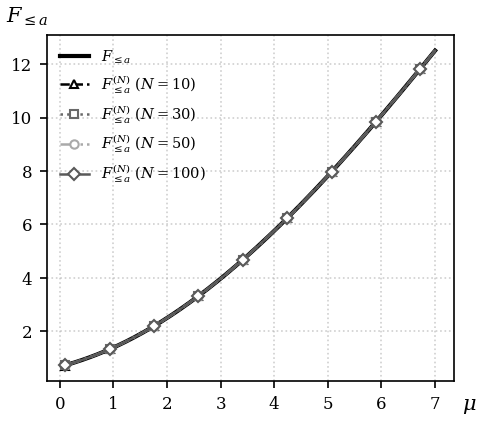

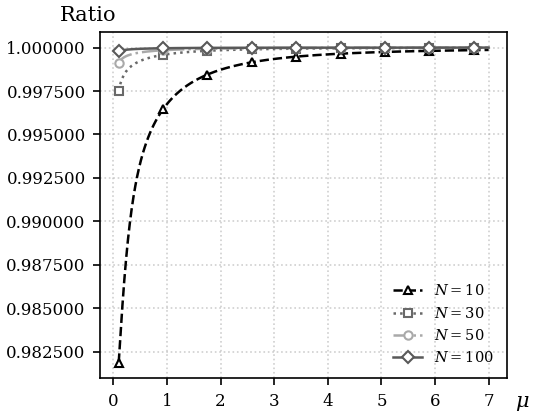

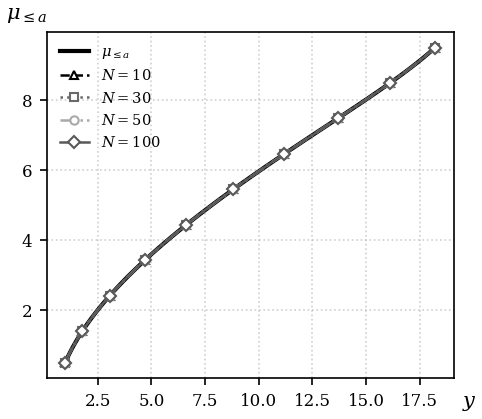

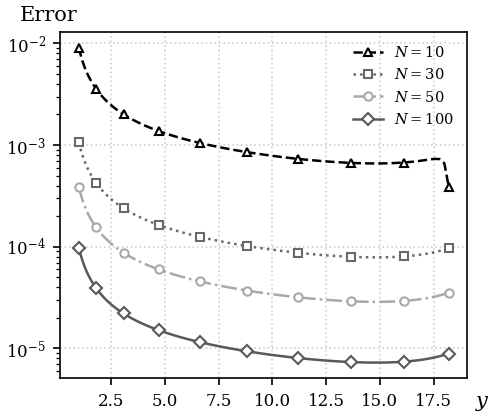

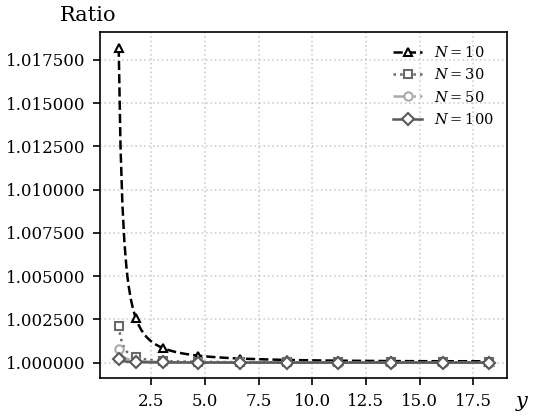

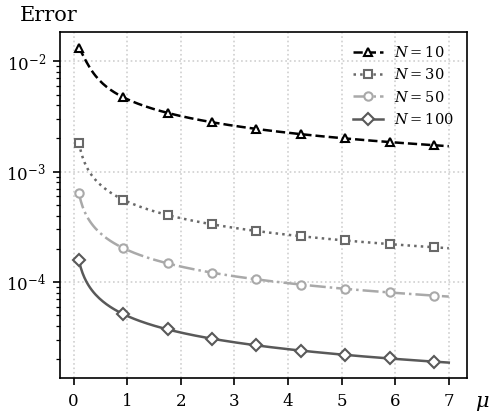

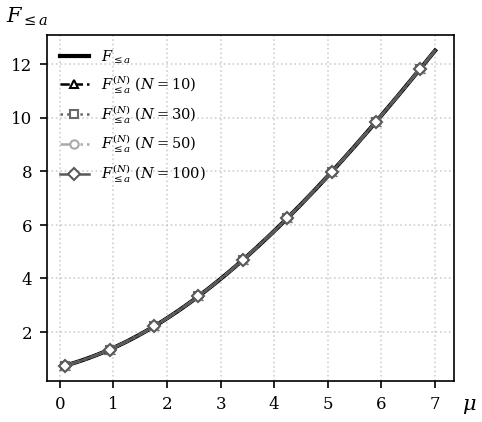

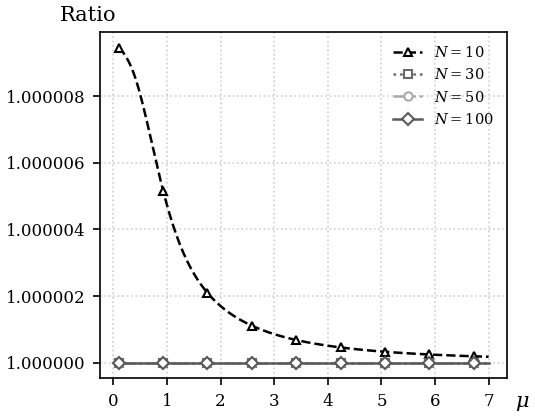

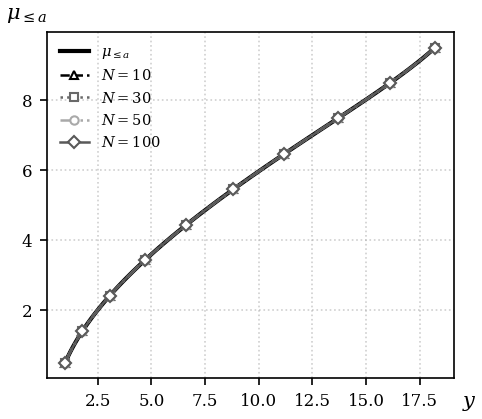

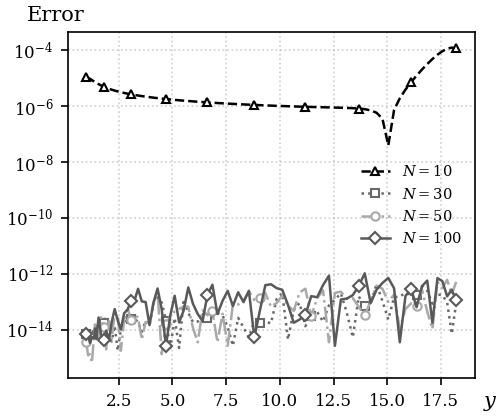

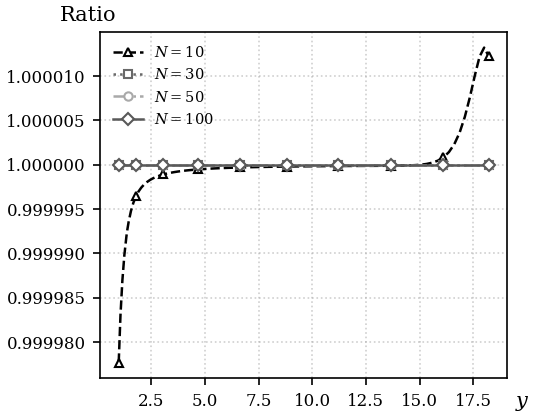

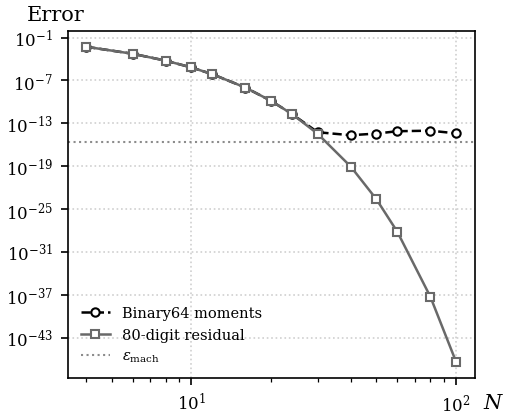

In [7]:
mu_grid=np.linspace(.1,7,201);refs=np.array([F_num(u,10) for u in mu_grid])
mu_inv=np.unique(np.r_[np.linspace(.5,9.5,81),1.]);targets=np.array([F_num(u,10) for u in mu_inv])
forward={};inverse={};forward_rows=[];inverse_rows=[]
for N in Ns:
 raw=np.array([safe_bounded_selvaggi(u,10,N) for u in mu_grid])
 spec=np.array([f_poisson(u,L=N//2) for u in mu_grid]);forward[N]=(raw,spec)
 ir=np.array([invert_selvaggi_safe(y,10,N) for y in targets])
 ip=np.array([invert_poisson_series(y,10,1,N) for y in targets]);inverse[N]=(ir,ip)
 for i,u in enumerate(mu_grid):
  forward_rows.append(dict(N=N,mu=u,reference=refs[i],selvaggi=raw[i],poisson=spec[i],
   selvaggi_error=abs(raw[i]-refs[i]),poisson_error=abs(spec[i]-refs[i])))
 for i,u in enumerate(mu_inv):
  inverse_rows.append(dict(N=N,true_mu=u,target=targets[i],selvaggi_mu=ir[i],poisson_mu=ip[i],
   selvaggi_error=abs(ir[i]-u),poisson_error=abs(ip[i]-u),
   poisson_original_integral_residual=abs(F_num(ip[i],10)-targets[i])))
write_csv('forward_grid.csv',forward_rows);write_csv('inverse_grid.csv',inverse_rows)
summary=[]
for N in Ns:
 f=[r for r in forward_rows if r['N']==N];v=[r for r in inverse_rows if r['N']==N]
 summary.append(dict(N=N,max_forward_selvaggi=max(r['selvaggi_error'] for r in f),
  max_forward_poisson=max(r['poisson_error'] for r in f),max_inverse_selvaggi=max(r['selvaggi_error'] for r in v),
  max_inverse_poisson=max(r['poisson_error'] for r in v)))
show_rows(summary);write_csv('error_summary.csv',summary)
def error_curve(ax,x,e,N):
 mask=e>0
 ax.semilogy(x[mask],e[mask],label=rf'$N={N}$',**style(N,len(x)))
 if not np.all(mask):print('Exact floating-point zeros omitted from log plot:',int(np.sum(~mask)), 'N=',N)
for kind,name in enumerate(['Selvaggi','Poisson']):
 fig,ax=plt.subplots();ax.plot(mu_grid,refs,'k-',lw=2,label=r'$F_{\leq a}$')
 for N in Ns:ax.plot(mu_grid,forward[N][kind],label=rf'$F_{{\leq a}}^{{(N)}}\ (N={N})$',**style(N,len(mu_grid)))
 labels(ax);ax.legend(frameon=False,fontsize=7);savefig(f'{kind+1}_Forward_{name}_Fits')
 fig,ax=plt.subplots()
 for N in Ns:ax.plot(mu_grid,forward[N][kind]/refs,label=rf'$N={N}$',**style(N,len(mu_grid)))
 labels(ax,y='Ratio');ax.legend(frameon=False,fontsize=7);savefig(f'{kind+3}_Forward_{name}_Ratio')
 fig,ax=plt.subplots();ax.plot(targets,mu_inv,'k-',lw=2,label=r'$\mu_{\leq a}$')
 for N in Ns:ax.plot(targets,inverse[N][kind],label=rf'$N={N}$',**style(N,len(targets)))
 labels(ax,x=r'$y$',y=r'$\mu_{\leq a}$');ax.legend(frameon=False,fontsize=7);savefig(f'{kind+5}_Inverse_{name}_Fits')
 fig,ax=plt.subplots()
 for N in Ns:error_curve(ax,targets,abs(inverse[N][kind]-mu_inv),N)
 labels(ax,x=r'$y$',y='Error');ax.legend(frameon=False,fontsize=7);savefig(f'{kind+7}_Inverse_{name}_Error')
 fig,ax=plt.subplots()
 for N in Ns:ax.plot(targets,inverse[N][kind]/mu_inv,label=rf'$N={N}$',**style(N,len(targets)))
 labels(ax,x=r'$y$',y='Ratio');ax.legend(frameon=False,fontsize=7);savefig(f'{kind+9}_Inverse_{name}_Ratio')
 if name=='Selvaggi':
  fig,ax=plt.subplots()
  for N in Ns:error_curve(ax,mu_grid,abs(forward[N][kind]-refs),N)
  labels(ax,y='Error');ax.legend(frameon=False,fontsize=7);savefig('11_Forward_Selvaggi_Error')

def poisson_residual_mp(mu,L,c=.5,a=10.,T=1.,dps=80):
 """Exact F-F_P residual for the binomial trace, evaluated at high precision."""
 with mp.workdps(dps):
  mu,c,a,T=map(mp.mpf,map(str,(mu,c,a,T)));L=int(L)
  def integrand(x):
   q=mp.exp(-abs(x-mu)/T)
   r=(-1)**L*q**(L+1)*(1-q)**(L-1)/(mp.mpf(2)**L*(1+q)**2)
   r*=((L+1)*(1-q)-2*L*q*q)
   return x**(c+1)*r/((c+1)*T)
  pts=[mp.mpf(0)]
  if 0<mu<a:pts.append(mu)
  pts.append(a)
  return +mp.quad(integrand,pts)

precision_modes=[4,6,8,10,12,16,20,24,30,40,50,60,80,100]
reference_mu1=mp_bounded(1,.5,10,1,80)
precision_audit=[]
for N in precision_modes:
 double_error=abs(mp.mpf(f_poisson(1,L=N//2))-reference_mu1)
 truncation_error=abs(poisson_residual_mp(1,N//2))
 precision_audit.append(dict(N=N,double_error=float(double_error),
  high_precision_truncation_error=float(truncation_error),exact_arithmetic_bound=poisson_bound(L=N//2)))
write_csv('poisson_precision_audit.csv',precision_audit)
fig,ax=plt.subplots()
ax.loglog(precision_modes,[r['double_error'] for r in precision_audit],
 'k--o',mfc='white',label='Binary64 moments')
ax.loglog(precision_modes,[r['high_precision_truncation_error'] for r in precision_audit],
 color='dimgray',ls='-',marker='s',mfc='white',label='80-digit residual')
ax.axhline(np.finfo(float).eps,color='0.55',ls=':',lw=1,label=r'$\epsilon_{\rm mach}$')
labels(ax,x=r'$N$',y='Error');ax.legend(frameon=False,fontsize=7)
savefig('12_Forward_Poisson_Error')

## 5. Bell-polynomial inverse: independent analytical test
The forward Taylor coefficients use logistic derivative polynomials, so they remain convergent at every derivative order for $c>-1$. Ordinary partial Bell polynomials are used with the convention $B_{n,j}=[t^n](\sum_{\ell\ge1}b_\ell t^\ell)^j$.

First check formal polynomial composition; then evaluate the explicit inverse polynomial on targets obtained from quadrature. **No root finder is used in either test.** The plot uses a local interval around $\mu_0=2$ and does not assert a global convergence radius.

c=-0.75 | composition_error=1.110223e-16
c=0 | composition_error=3.469447e-18
c=0.5 | composition_error=3.0357661e-18
c=1.5 | composition_error=4.3368087e-19


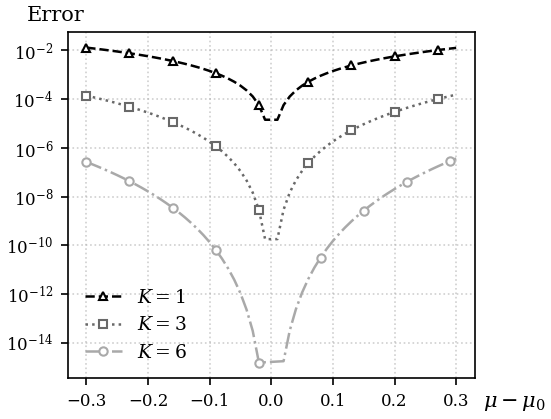

In [8]:
bell=[];bell_checks=[];mu0=2.;offsets=np.linspace(-.3,.3,61)
for c in [-.75,0,.5,1.5]:
 aa=forward_taylor(mu0,c=c,K=6);co=inverse_coefficients(aa)
 composed=np.zeros(7)
 for j in range(1,7):
  term=poly.polypow(np.r_[0,co],j)[:7]
  composed[:len(term)]+=aa[j]*term
 err=max(abs(composed-np.r_[0,1,np.zeros(5)]));assert err<2e-10
 bell_checks.append(dict(c=c,composition_error=err))
 for u in mu0+offsets:
  y=f_quad(u,c=c)
  for K in [1,3,6]:
   v=inverse_taylor(y,mu0,aa,co[:K])
   bell.append(dict(c=c,K=K,true_mu=u,target=y,inverse=v,error=abs(v-u)))
show_rows(bell_checks);write_csv('bell_composition.csv',bell_checks);write_csv('bell_inverse.csv',bell)
fig,ax=plt.subplots()
for K,N in [(1,10),(3,30),(6,50)]:
 rows=[r for r in bell if r['c']==.5 and r['K']==K];e=np.array([r['error'] for r in rows]);mask=e>0
 ax.semilogy(offsets[mask],e[mask],label=rf'$K={K}$',**style(N,len(offsets)))
labels(ax,x=r'$\mu-\mu_0$',y='Error');ax.legend(frameon=False);savefig('13_Bell_Analytic_Inverse_Error')

## 6. Sommerfeld inverse: coefficients and asymptotic test
The target here is unnormalized. Set $u=[(c+1)(y+R_c)]^{1/(c+1)}$ with the exact temperature-scaled tail. The coefficient equation is $\sum_{k\ge0}A_k\varepsilon^k r^{c+1-2k}=1$.
$$b_1=-c\alpha_1,\qquad b_2=c(c-2)\left[\tfrac c2\alpha_1^2-(c-1)\alpha_2\right].$$
The code checks coefficients through third order and uses the **implicit asymptotic fixed-point formula**, not Brent inversion of an exact forward function. Convergence is checked for each run and exceptions are not hidden. This is an interior low-temperature experiment, not an endpoint-uniform or global fixed-point convergence claim.

T=1 | K=1 | true_mu=8 | inverse=8.0026643 | error=0.0026643324 | iterations=4
T=1 | K=2 | true_mu=8 | inverse=8.0003767 | error=0.00037667379 | iterations=4
T=1 | K=3 | true_mu=8 | inverse=8.0001146 | error=0.00011459745 | iterations=4
T=0.5 | K=1 | true_mu=8 | inverse=8.000152 | error=0.00015196815 | iterations=3
T=0.5 | K=2 | true_mu=8 | inverse=8.0000048 | error=4.7609161e-06 | iterations=3
T=0.5 | K=3 | true_mu=8 | inverse=8.0000005 | error=4.6211597e-07 | iterations=3
T=0.25 | K=1 | true_mu=8 | inverse=8.0000093 | error=9.3367839e-06 | iterations=2
T=0.25 | K=2 | true_mu=8 | inverse=8.0000001 | error=6.9491771e-08 | iterations=2
T=0.25 | K=3 | true_mu=8 | inverse=8 | error=1.507761e-09 | iterations=2
T=0.125 | K=1 | true_mu=8 | inverse=8.0000006 | error=5.8132492e-07 | iterations=2
T=0.125 | K=2 | true_mu=8 | inverse=8 | error=1.0711609e-09 | iterations=2
T=0.125 | K=3 | true_mu=8 | inverse=8 | error=5.7056582e-12 | iterations=2


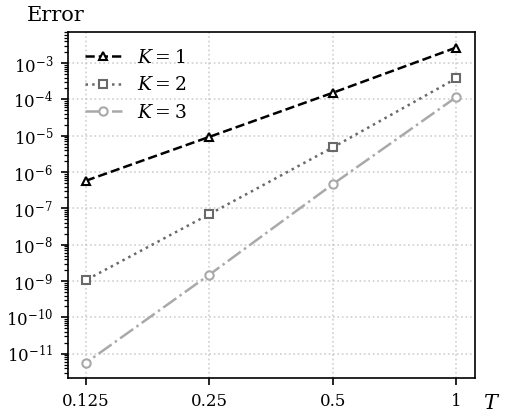

In [9]:
for c in [-.75,0,.5,1,2.3]:
 A,b=sommerfeld_coefficients(c,3)
 assert abs(b[0]+c*np.pi**2/6)<2e-13
 assert abs(b[1]-c*(c-2)*(c/2*(np.pi**2/6)**2-(c-1)*7*np.pi**4/360))<2e-12
 r=np.r_[1,b]
 for n in range(1,4):
  assert abs(sum(A[k]*series_power(r,c+1-2*k,n-k)[n-k] for k in range(n+1)))<2e-9
somm=[]
for T in [1.,.5,.25,.125]:
 target=float(mp_bounded(8,.5,20,T,60))
 for K in [1,2,3]:
  v,it=sommerfeld_inverse(target,.5,20,T,K)
  somm.append(dict(T=T,K=K,true_mu=8.,inverse=v,error=abs(v-8),iterations=it))
show_rows(somm);write_csv('sommerfeld_inverse.csv',somm)
fig,ax=plt.subplots()
for K,N in [(1,10),(2,30),(3,50)]:
 rows=[r for r in somm if r['K']==K]
 ax.loglog([r['T'] for r in rows],[r['error'] for r in rows],label=rf'$K={K}$',**style(N,4))
from matplotlib.ticker import NullLocator
ax.set_xticks([.125,.25,.5,1.]);ax.set_xticklabels(['0.125','0.25','0.5','1'])
ax.xaxis.set_minor_locator(NullLocator())
labels(ax,x=r'$T$',y='Error');ax.legend(frameon=False);savefig('14_Sommerfeld_Analytic_Inverse_Error')

## 7. Endpoint repair and raw-series convergence
These figures make the practical corrections visible: the Poisson comparison uses identical 10-mode budgets and the convergence plot reports the unaccelerated half-order series at the original counterexample. The measured tables, rather than a prescribed tolerance, are the source for numerical claims.

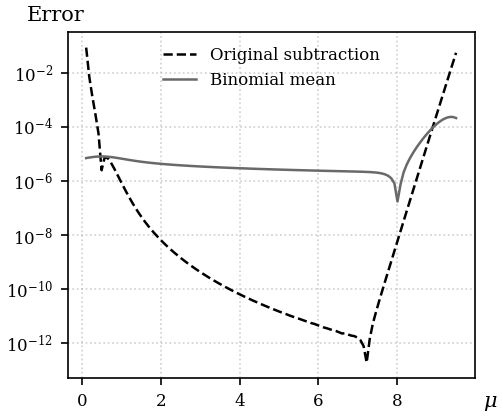

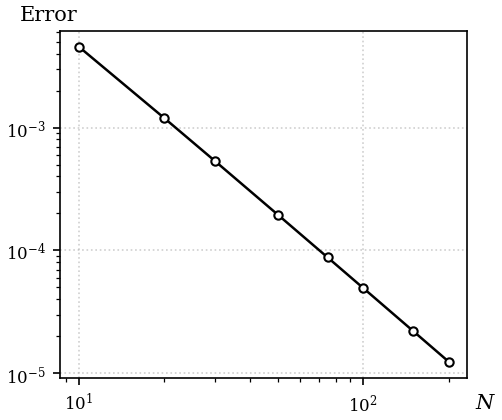

In [10]:
edge_mu=np.linspace(.1,9.5,121)
old_e=np.array([abs(legacy['F_poisson_regularized'](u,10,N=10)-F_num(u,10)) for u in edge_mu])
new_e=np.array([abs(f_poisson(u,L=5)-F_num(u,10)) for u in edge_mu])
write_csv('poisson_endpoint_grid.csv',[dict(mu=u,old_error=e,new_error=v) for u,e,v in zip(edge_mu,old_e,new_e)])
fig,ax=plt.subplots()
ax.semilogy(edge_mu,old_e,'--',color='black',label='Original subtraction')
ax.semilogy(edge_mu,new_e,'-',color='dimgray',label='Binomial mean')
labels(ax,y='Error');ax.legend(frameon=False,fontsize=8);savefig('15_Poisson_Endpoint_Repair_N10')
conv=[]
for N in [10,20,30,50,75,100,150,200]:
 v=f_half(1,N=N);hi=mp_bounded(1,dps=60)
 conv.append(dict(N=N,approximation=v,absolute_error=float(abs(mp.mpf(v)-hi))))
write_csv('selvaggi_convergence.csv',conv)
fig,ax=plt.subplots();ax.loglog([r['N'] for r in conv],[r['absolute_error'] for r in conv],'k-o',mfc='white')
labels(ax,x=r'$N$',y='Error');savefig('16_Selvaggi_Raw_Convergence')

## 8. Generalized complete function from Hurwitz zeta: all seven orders
The requested seven curves cannot all be finite unnormalized defining integrals: the integrals diverge for $c\le-1$, and the unnormalized continuation has a pole at $c=-1$. Therefore the overlay uses the explicitly normalized complete function
$$\mathfrak F_c(\mu)=-\operatorname{Li}_{c+1}(-e^\mu),$$
which agrees with the complete integral divided by $\Gamma(c+1)$ for $c>-1$ and defines its analytic continuation below that range. It is **not the bounded function** plotted above.

The curves are evaluated through the manuscript's normalized Hurwitz expression, with special care at removable singularities:
$$\mathfrak F_c(\mu)=\frac{2\pi(2\pi)^c}{\Gamma(c+1)\sin(\pi c)}\operatorname{Re}\left[e^{-i\pi c/2}\zeta\left(-c,\tfrac12-\tfrac{i\mu}{2\pi}\right)\right].$$
For $c=0,1$, use the derivative limit in the order, not a floating-point division by zero. At $c=-1$, the normalized limit is $1/(1+e^{-\mu})$; it is also checked by approaching the order from both sides. At $c=-3/2$ this is analytic continuation, not an improper integral value.

References: [NIST DLMF 25.12.13](https://dlmf.nist.gov/25.12.E13), the Hurwitz/polylogarithm relation, and [25.12.14–16](https://dlmf.nist.gov/25.12#iii), normalized Fermi–Dirac conventions. Independent polylogarithm and convergent-integral/derivative checks are used below. These numerical identities do not repair the manuscript's keyhole-contour proof by themselves.

35 Hurwitz/polylogarithm and integral/derivative checks passed at 60 digits.
Largest absolute cross-check difference: 1.9913648889155653e-59


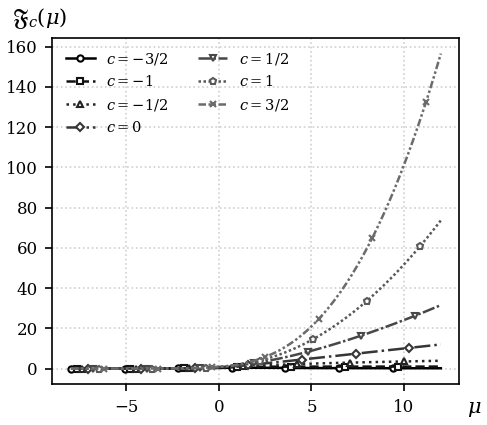

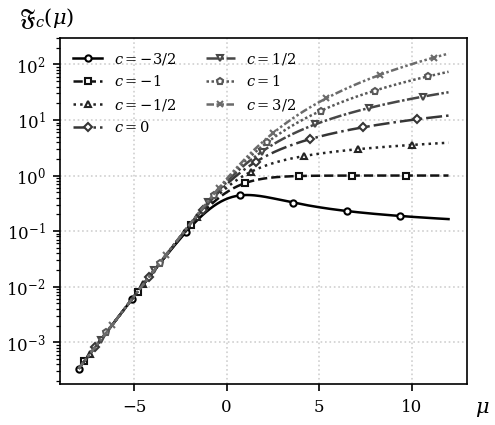

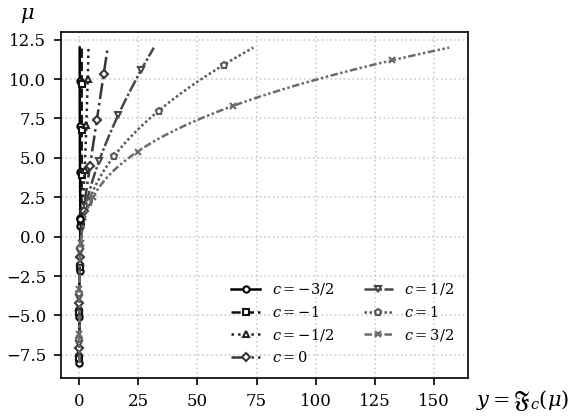

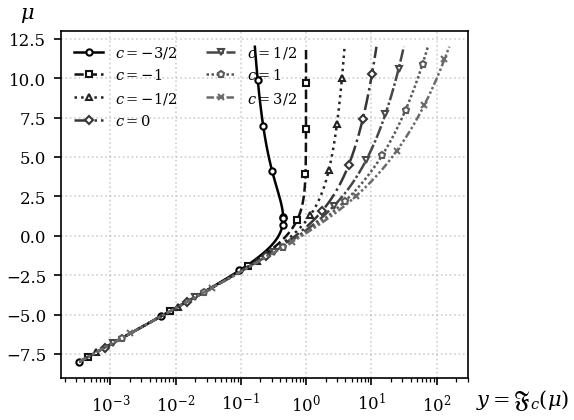

In [11]:
def hurwitz_normalized(c,mu,dps=40):
 with mp.workdps(dps):
  c=mp.mpf(str(c));mu=mp.mpf(str(mu));q=mp.mpf('.5')-1j*mu/(2*mp.pi)
  H=lambda v:mp.re(mp.exp(-1j*mp.pi*v/2)*mp.zeta(-v,q))
  if c==-1:return +(1/(1+mp.exp(-mu)))
  if c in (0,1):
   return +(2*(2*mp.pi)**c*(-1)**int(c)*mp.diff(H,c)/mp.gamma(c+1))
  return +(2*mp.pi*(2*mp.pi)**c*H(c)/(mp.gamma(c+1)*mp.sin(mp.pi*c)))

horders=[-1.5,-1.,-.5,0.,.5,1.,1.5]
hchecks=[]
for c in horders:
 for mu in [-8.,-2.,0.,2.,12.]:
  v=hurwitz_normalized(c,mu,60)
  with mp.workdps(60):
   reference=-mp.polylog(mp.mpf(str(c))+1,-mp.exp(mu))
   error=abs(v-reference)
   assert error<mp.mpf('1e-45')*(1+abs(reference))
   # Independent integral for admissible half-orders, derivative integral for -3/2.
   if c>-1:
    fun=lambda t:2*t**(2*c+1)/(1+mp.exp(t*t-mu))/mp.gamma(c+1)
    integral=mp.quad(fun,[0,1,4,mp.inf])
   elif c==-1:integral=1/(1+mp.exp(-mu))
   else:
    fun=lambda t:2/mp.sqrt(mp.pi)*mp.exp(t*t-mu)/(1+mp.exp(t*t-mu))**2
    integral=mp.quad(fun,[0,1,4,mp.inf])
   assert abs(v-integral)<mp.mpf('1e-40')*(1+abs(integral))
   hchecks.append(dict(c=c,mu=mu,hurwitz=float(v),polylog_difference=float(error),integral_difference=float(abs(v-integral))))
with mp.workdps(60):
 for mu in [-2,0,2]:
  delta=mp.mpf('1e-15')
  near=(hurwitz_normalized(-1-delta,mu,60)+hurwitz_normalized(-1+delta,mu,60))/2
  assert abs(near-hurwitz_normalized(-1,mu,60))<mp.mpf('1e-27')
write_csv('hurwitz_validation.csv',hchecks)
print('35 Hurwitz/polylogarithm and integral/derivative checks passed at 60 digits.')
print('Largest absolute cross-check difference:',max(r['polylog_difference'] for r in hchecks))
hmu=np.linspace(-8,12,201);hrows=[];hvals={}
for c in horders:
 hvals[c]=np.array([float(hurwitz_normalized(c,u)) for u in hmu])
 for u,v in zip(hmu,hvals[c]):hrows.append(dict(c=c,mu=u,normalized_complete=v))
write_csv('hurwitz_orders.csv',hrows)
order_labels=[r'-3/2',r'-1',r'-1/2',r'0',r'1/2',r'1',r'3/2']
order_styles=[('-', 'o'),('--','s'),(':','^'),('-.','D'),((0,(5,1,1,1)),'v'),((0,(1,1)),'p'),((0,(3,1,1,1,1,1)),'x')]
for log,name in [(False,'17_Hurwitz_Generalized_Orders'),(True,'18_Hurwitz_Generalized_Orders_Log')]:
 fig,ax=plt.subplots()
 for i,c in enumerate(horders):
  ls,mk=order_styles[i]
  ax.plot(hmu,hvals[c],ls=ls,marker=mk,markevery=(i*3,29),color=str(.07*i),mfc='white',ms=3,label=rf'$c={order_labels[i]}$')
 if log:ax.set_yscale('log')
 labels(ax,y=r'$\mathfrak{F}_c(\mu)$');ax.legend(frameon=False,fontsize=7,ncol=2,loc='upper left')
 savefig(name)

# The c=-3/2 continuation has a single turning point and hence two real
# inverse branches. The other six displayed orders are monotone.
with mp.workdps(60):
 derivative=lambda u:mp.re(-mp.polylog(mp.mpf('-1.5'),-mp.exp(u)))
 turn_mu=mp.findroot(derivative,(mp.mpf('1'),mp.mpf('1.3')),solver='anderson',verify=False)
 turn_value=hurwitz_normalized(-1.5,turn_mu,60)
 assert abs(derivative(turn_mu))<mp.mpf('1e-40')

inverse_checks=[]
for c in horders:
 test_mus=[-6.,-2.,0.,2.,8.] if c!=-1.5 else [-6.,-2.,0.,1.,2.,5.,10.]
 for true_mu in test_mus:
  target=hurwitz_normalized(c,true_mu,60)
  with mp.workdps(60):
   root=mp.findroot(lambda u:hurwitz_normalized(c,u,60)-target,
    (mp.mpf(str(true_mu-.08)),mp.mpf(str(true_mu+.08))),verify=False)
   err=abs(root-mp.mpf(str(true_mu)))
   assert err<mp.mpf('1e-35')
  branch='lower' if c==-1.5 and true_mu<float(turn_mu) else ('upper' if c==-1.5 else 'monotone')
  inverse_checks.append(dict(c=c,branch=branch,target=float(target),true_mu=true_mu,
   recovered_mu=float(root),absolute_error=float(err)))
write_csv('hurwitz_inverse_validation.csv',inverse_checks)

# Insert the exact turning point so both c=-3/2 branches meet without a
# sampling artifact. Plotting x=F_c(mu), y=mu gives the inverse relation.
inverse_rows=[]
for c in horders:
 if c==-1.5:
  mus=np.unique(np.r_[hmu,float(turn_mu)])
 else:mus=hmu
 vals=np.array([float(hurwitz_normalized(c,u)) for u in mus])
 for u,v in zip(mus,vals):
  branch='lower' if c==-1.5 and u<=float(turn_mu) else ('upper' if c==-1.5 else 'monotone')
  inverse_rows.append(dict(c=c,branch=branch,normalized_complete=v,mu=u))
write_csv('hurwitz_inverse_orders.csv',inverse_rows)
for log,name in [(False,'19_Hurwitz_Generalized_Inverse'),(True,'20_Hurwitz_Generalized_Inverse_Log')]:
 fig,ax=plt.subplots()
 for i,c in enumerate(horders):
  ls,mk=order_styles[i]
  rows=[r for r in inverse_rows if r['c']==c]
  if c==-1.5:
   for j,branch in enumerate(['lower','upper']):
    rr=[r for r in rows if r['branch']==branch]
    ax.plot([r['normalized_complete'] for r in rr],[r['mu'] for r in rr],
     ls=ls,marker=mk,markevery=(i*3,29),color=str(.07*i),mfc='white',ms=3,
     label=rf'$c={order_labels[i]}$' if j==0 else '_nolegend_')
  else:
   ax.plot([r['normalized_complete'] for r in rows],[r['mu'] for r in rows],
    ls=ls,marker=mk,markevery=(i*3,29),color=str(.07*i),mfc='white',ms=3,
    label=rf'$c={order_labels[i]}$')
 ax.plot(float(turn_value),float(turn_mu),'ko',ms=3,mfc='white')
 if log:ax.set_xscale('log')
 labels(ax,x=r'$y=\mathfrak{F}_c(\mu)$',y=r'$\mu$')
 ax.legend(frameon=False,fontsize=7,ncol=2,loc='upper left' if log else 'lower right')
 savefig(name)

## 9. Reproducibility manifest and limits
The manuscript must report the measured tables and actual tolerances from this notebook. Mode counts for the new Poisson method refer to the largest Fourier index N=2L, not the number of averaged partial sums. No universal near-machine-precision claim follows from a few accurate interior values.

The 20 PDF/SVG figures and their CSV datasets are self-generated. The original scripts and manuscripts have not been overwritten. The Hurwitz curves use normalized continuation, while bounded numerical comparisons use unnormalized integrals. The $c=-3/2$ inverse is explicitly two-branched. Bell tests and Sommerfeld tests are separately identified. Extremely ill-conditioned inverse targets close to zero or saturation need separate precision analysis; the finite grids here do not certify that regime.

In [12]:
manifest=dict(versions=versions,tolerances=dict(quad_epsabs=QUAD_EPS,quad_epsrel=QUAD_EPS,
 brent_xtol=ROOT_XTOL,brent_rtol=ROOT_RTOL),
 normalizations={'bounded':'unnormalized','Hurwitz':'normalized complete analytic continuation'},
 poisson_summation='Binomial mean of S_L through S_2L; N=2L Fourier modes',
 grids={'forward_points':len(mu_grid),'inverse_points':len(mu_inv),'general_order_cases':len(general)},
 original_failure_comparison=audit,error_summary=summary,figures=figure_names)
# JSON does not permit NaN: retain the explicit status and encode original failures as null.
clean=json.loads(json.dumps(manifest,default=str),parse_constant=lambda _:None)
(DATA/'manifest.json').write_text(json.dumps(clean,indent=2,allow_nan=False))
assert len(figure_names)==20
for name in figure_names:
 for ext in ('pdf','svg','png'):assert (FIG/(name+'.'+ext)).is_file()
print('PASS: all executed assertions; 20 PDF, 20 SVG and 20 PNG figures; CSV data and manifest saved.')
print('See data/error_summary.csv for the numerical section. No 1e-15 accuracy promise is inferred from solver settings.')

PASS: all executed assertions; 20 PDF, 20 SVG and 20 PNG figures; CSV data and manifest saved.
See data/error_summary.csv for the numerical section. No 1e-15 accuracy promise is inferred from solver settings.
